# Extract every row from dense pages

A stock count runs 70 rows to a page, and its two pages are scans with no text to copy. Send each page to TypeLLM as an image and read back every row as typed data: a SKU, an item and a count.

One read can stop before the page ends: an array returns at most 50 new items per call. So after each read, ask whether the page has a row after the last one, and read that row in the same call. If it does, carry on reading from there; if not, the page is done.

1. Describe a row.
2. Read a page, then ask what comes next.
3. Check the rows against the page footer.

Paste your TypeLLM API key in the cell below, then run all cells.

In [1]:
%pip install -q "typellm>=0.6.9" pymupdf

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Paste your API key here.
TYPELLM_API_KEY = ""  # https://typellm.ai/dashboard/keys

In [3]:
import os
import urllib.request

import pymupdf
from typellm import TypeLLMClient

client = TypeLLMClient(api_key=TYPELLM_API_KEY, timeout=90)

PDF = "data/stock_count.pdf"
if not os.path.exists(PDF):
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/TypeLLM/TypeLLM/main/examples/notebooks/data/stock_count.pdf", PDF)

doc = pymupdf.open(PDF)
print(f"{doc.page_count} pages, text layer: {doc[0].get_text()!r}")

2 pages, text layer: ''


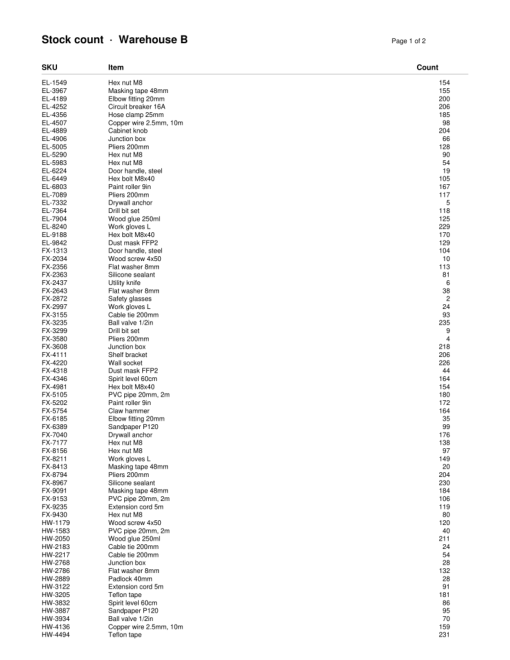

In [4]:
from IPython.display import Image

Image(doc[0].get_pixmap(dpi=60).tobytes("png"))

## Describe a row

`ROW` holds a row's properties. `ROWS` is an array of them, and `NEXT_ROW` asks for the row after a given one: `has_next` says whether there is one, and the row's properties are asked only `when` it is true.

In [5]:
CONTEXT = "One scanned page of a stock count."
ROW = {"sku": {"type": "string"}, "item": {"type": "string"}, "count": {"type": "integer"}}
ROWS = {"type": "array", "items": {"type": "object", "properties": ROW},
        "instructions": "Every row of the stock count on this page, in order."}

def next_row(last):
    questions = {"has_next": {"type": "boolean", "thinking": "auto", "instructions":
        f"The last row read so far is {last['sku']} {last['item']} {last['count']}. Is there another row below it on this page?"}}
    for name, field in ROW.items():
        questions[name] = {**field, "when": {"has_next": True}, "instructions": f"The next row's {name}."}
    return questions

## Read a page, then ask what comes next

Each read passes the page's rows so far as `continue_from`, so it picks up where the last one stopped. After each read, `next_row` asks about the row after the last one. A page is done when there is none.

In [6]:
def read_page(image):
    rows = []
    while True:
        rows = client.generate(context=CONTEXT, images=[image],
                               questions={"rows": {**ROWS, "continue_from": rows}}).result["rows"]
        print(f"  read up to row {len(rows)}")
        answer = client.generate(context=CONTEXT, images=[image], questions=next_row(rows[-1])).result
        row = {name: answer.get(name) for name in ROW}
        if not answer["has_next"] or row in rows:
            print("  no row after it")
            return rows
        rows.append(row)
        print(f"  row {len(rows)} after it: {row['sku']}")

rows = []
for number, page in enumerate(doc, 1):
    print(f"page {number}")
    rows += read_page(page.get_pixmap(dpi=200).tobytes("png"))

page 1


  read up to row 50


  row 51 after it: FX-8967


  read up to row 70


  no row after it
page 2


  read up to row 50


  row 51 after it: TL-2286


  read up to row 70


  no row after it


## Check against the footer

The last page ends with the number of lines and units counted.

140 rows, 16,351 units


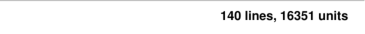

In [7]:
print(f"{len(rows)} rows, {sum(row['count'] for row in rows):,} units")
Image(doc[-1].get_pixmap(dpi=100, clip=pymupdf.Rect(300, 768, 562, 792)).tobytes("png"))